In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("EternalReturn_kakaogames_2024.csv")

In [4]:
df

,gameId,userNum,nickname,matchingTeamMode,characterNum,skinCode,characterLevel,gameRank,playerKill,playerAssistant,...,mmrGainInGame,mmrLossEntryCost,premadeMatchingType,viewContribution,useReconDrone,useEmpDrone,exceptPreMadeTeam,terminateCount,clutchCount,isLeavingBeforeCreditRevivalTerminate
0,35260427,4378745,쏘히,3,49,1049003,20,5,6,1,...,30,-44,1,21,3,0,False,0,0,False
1,35260427,4313007,쏘금,3,28,1028000,20,4,2,6,...,69,-44,1,27,6,0,False,1,0,False
2,35260427,4227659,어지럽네,3,23,1023002,20,2,2,8,...,128,-43,1,18,4,0,False,0,0,False
3,35260427,3979035,微笑的高圆圆,3,53,1053000,20,1,4,3,...,124,-43,1,31,6,0,False,1,0,False
4,35260427,2118488,minom1,3,65,1065001,20,1,2,4,...,124,-43,1,25,7,0,False,1,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204420,35765219,3927798,Toasty117,3,68,1068000,1,3,0,0,...,0,0,0,0,0,0,False,0,0,True
204421,35783095,4932642,1펀치쓰리강냉이,3,36,1036000,1,7,0,0,...,0,0,0,0,0,0,False,0,0,True
204422,35796912,456574,Luliet,3,74,1074000,1,8,0,0,...,0,0,0,0,0,0,False,0,0,True
204423,35804415,4519640,수원대장서예슬,3,8,1008000,1,8,0,0,...,0,-72,1,0,0,0,False,0,0,True


<Axes: >

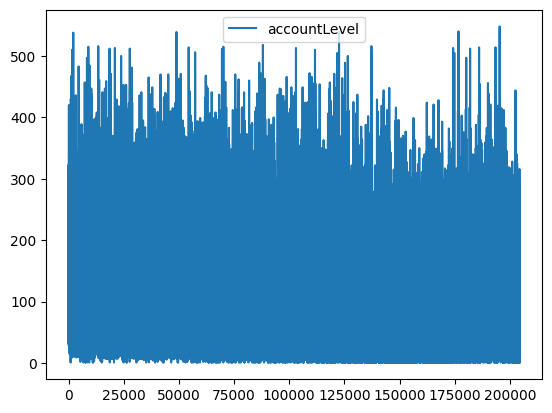

In [5]:
df[['accountLevel']].plot()

In [6]:
df['characterLevel'].sort_values(ascending=False)

0         20
18946     20
18957     20
18956     20
18955     20
          ..
204396     1
204397     1
204398     1
204399     1
204424     1
Name: characterLevel, Length: 204425, dtype: int64

In [7]:
df['battleZone1AreaCode'].value_counts()

battleZone1AreaCode
0      116940
190      5268
150      4999
100      4936
110      4933
60       4888
170      4754
90       4736
40       4686
130      4646
80       4627
20       4612
180      4596
160      4566
120      4541
30       4368
140      4287
50       4194
10       3958
70       3890
Name: count, dtype: int64

In [8]:
df['battleZone1Winner'].value_counts()

battleZone1Winner
0    146369
1     58056
Name: count, dtype: int64

In [9]:
# 실력별 세그먼트 분류 위해 0점, 1~2000점, 
# 2001~4000점, 4001~6000점, 6001+로 5개의 세그먼트로 분류
# (이상치/결측치 없음, 분류 기준은 추후 변경 가능)
bins = [-1, 2400, 3600, 6400,np.inf]
labels = ['아이언&브론즈', '실버&골드', '플래티넘&다이아', '메테오라이트+']

df['rank_group'] = pd.cut(
    df['rankPoint'],
    bins=bins,
    labels=labels
    )

df['rank_group']

df['rank_type'] = np.where(
    (df['mmrGainInGame'] == 0) & (df['mmrLossEntryCost'] == 0),
    'rank_none','rank_game')

# 1. 우선 게임 단위로 
# mmr 수치 중에 하나라도 mmr이 0이 아니라면
game_rank_flag = (
    df
    .groupby("gameId")
    .apply(
        lambda x: (
            (x["mmrGainInGame"] != 0).any() or
            (x["mmrLossEntryCost"] != 0).any()
        )
    )
    .reset_index(name="is_rank_game")
)

# 통째로 df1에 merge
df1 = df.merge(game_rank_flag, on="gameId", how="left")

# 랭크게임 여부를 확인하는 rank_type_v2 컬럼 추가
df1["rank_type_v2"] = df1["is_rank_game"].map(
    {True: "rank_game", False: "rank_none"}
)

df1["rank_type_v2"].value_counts()


C:\Users\for\AppData\Local\Temp\ipykernel_5924\1885529603.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


rank_type_v2
rank_none    117995
rank_game     86430
Name: count, dtype: int64

In [10]:
df['rank_group']

0         플래티넘&다이아
1         플래티넘&다이아
2         플래티넘&다이아
3         플래티넘&다이아
4         플래티넘&다이아
            ...   
204420     아이언&브론즈
204421     아이언&브론즈
204422     아이언&브론즈
204423    플래티넘&다이아
204424     아이언&브론즈
Name: rank_group, Length: 204425, dtype: category
Categories (4, object): ['아이언&브론즈' < '실버&골드' < '플래티넘&다이아' < '메테오라이트+']

In [11]:
df.isnull().sum()[lambda x : x > 0]

nickname                 3
language                37
killer                7601
killDetail            7608
causeOfDeath         21268
placeOfDeath          7602
killerCharacter       8863
killerWeapon          9718
killer2              64909
killDetail2          64909
causeOfDeath2        76383
placeOfDeath2        64906
killerCharacter2     66102
killerWeapon2        66685
killer3             123667
killDetail3         123667
causeOfDeath3       130934
placeOfDeath3       123667
killerCharacter3    124405
killerWeapon3       124718
dtype: int64

In [12]:
df['language']

0                     Korean
1                     Korean
2                     Korean
3          ChineseSimplified
4                     Korean
                 ...        
204420               English
204421                Korean
204422    ChineseTraditional
204423                Korean
204424               Russian
Name: language, Length: 204425, dtype: object

In [13]:
# 닉네임 결측치 확인
df[df['nickname'].isna()]

# 닉네임 별 대체 위해 userNum=1369612 중 nickname을 갖는 것이 있는지 확인 : 전체 Null이다.
df[df['userNum'] == 1369612]

# 참조하여 대체가 아닌 특정 값으로 대체하여 사용
df['nickname'] = df['nickname'].fillna('user1369612')

In [14]:
df['nickname'].isnull().sum()

0

In [15]:
df['killDetail']

0              너구리사냥
1               어지럽네
2             ちょうちょう
3              ooooo
4              밝은보름달
             ...    
204420        Uptown
204421     Warehouse
204422    GasStation
204423        School
204424        School
Name: killDetail, Length: 204425, dtype: object

In [16]:
df['killerUserNum']

0         1549251
1         4227659
2          988185
3          108836
4          666326
           ...   
204420          0
204421          0
204422          0
204423          0
204424          0
Name: killerUserNum, Length: 204425, dtype: int64

In [17]:
df['killer']

0                 player
1                 player
2                 player
3                 player
4                 player
               ...      
204420    restrictedArea
204421    restrictedArea
204422    restrictedArea
204423    restrictedArea
204424    restrictedArea
Name: killer, Length: 204425, dtype: object

In [18]:
df['causeOfDeath']

0                        쇼이치 기본공격
1                         이머전시 OP
2                           몽환 나비
3                             NaN
4                     basicAttack
                   ...           
204420    restrictedAreaExplosion
204421    restrictedAreaExplosion
204422    restrictedAreaExplosion
204423    restrictedAreaExplosion
204424    restrictedAreaExplosion
Name: causeOfDeath, Length: 204425, dtype: object

In [19]:
df['placeOfDeath']

0         180.0
1         110.0
2          50.0
3         170.0
4          50.0
          ...  
204420     60.0
204421     20.0
204422     80.0
204423    190.0
204424    190.0
Name: placeOfDeath, Length: 204425, dtype: float64

In [20]:
df['killerCharacter']

0         Shoichi
1           Cathy
2           Vanya
3            Yuki
4          Echion
           ...   
204420        NaN
204421        NaN
204422        NaN
204423        NaN
204424        NaN
Name: killerCharacter, Length: 204425, dtype: object

In [21]:
df['killerWeapon']

0         OneHandSword
1         OneHandSword
2               Arcana
3         TwoHandSword
4                VFArm
              ...     
204420             NaN
204421             NaN
204422             NaN
204423             NaN
204424             NaN
Name: killerWeapon, Length: 204425, dtype: object

In [22]:
df['versionMajor'].value_counts()

versionMajor
23    117551
22     86874
Name: count, dtype: int64

In [23]:
df['versionMinor'].value_counts()

versionMinor
0    117551
1     86874
Name: count, dtype: int64

In [24]:
df['startDtm'].sort_values()

61041     2024-05-30T15:33:02.002+0900
163878    2024-05-30T15:33:02.002+0900
163879    2024-05-30T15:33:02.002+0900
170624    2024-05-30T15:33:02.002+0900
61042     2024-05-30T15:33:02.002+0900
                      ...             
143021    2024-06-12T23:09:46.046+0900
128222    2024-06-12T23:09:46.046+0900
128221    2024-06-12T23:09:46.046+0900
28418     2024-06-12T23:09:46.046+0900
110753    2024-06-12T23:09:46.046+0900
Name: startDtm, Length: 204425, dtype: object

In [25]:
# bool, 1=victory
df['victory']

0         0
1         0
2         0
3         1
4         1
         ..
204420    0
204421    0
204422    0
204423    0
204424    0
Name: victory, Length: 204425, dtype: int64

In [26]:
df['characterNum'].value_counts().sort_index(ascending=True)

characterNum
1     3781
2     7309
3     1594
4     4631
5      789
      ... 
70    3144
71    4339
72    7112
73    2878
74    7422
Name: count, Length: 74, dtype: int64

In [27]:
df['tacticalSkillGroup'].value_counts().sort_index()

tacticalSkillGroup
30        83306
40         6537
50         6456
60        21451
70        18307
80        17685
90          136
110        3360
120        7122
130       17180
140        6145
150        5052
500120     6139
500130     1060
500140      355
500150     1101
500190      913
500200     1024
500220     1096
Name: count, dtype: int64

In [28]:
## skillLevelinfo -> 언어데이터로 맵핑
## df['skillLevelinfo_named']

import ast
from pathlib import Path

def load_l10n_from_file(path: str, encoding="utf-8-sig") -> dict[str, str]:
    text = Path(path).read_text(encoding=encoding)
    l10n = {}
    for line in text.splitlines():
        if "┃" not in line:
            continue
        k, v = line.split("┃", 1)
        l10n[k] = v
    return l10n

def extract_skill_group_names(l10n: dict) -> dict[int, str]:
    prefix = "Skill/Group/Name/"
    out = {}
    for k, v in l10n.items():
        if k.startswith(prefix):
            suffix = k[len(prefix):]
            if suffix.isdigit():
                out[int(suffix)] = v
    return out

df = pd.read_csv("EternalReturn_kakaogames_2024.csv")  

l10n = load_l10n_from_file("l10n-Korean-20260108051557.txt")
skill_name_map = extract_skill_group_names(l10n)

def parse_skilllevelinfo_cell(x):
    if pd.isna(x) or x == "" or x == "{}":
        return {}
    if isinstance(x, dict):
        d = x
    else:
        d = ast.literal_eval(x)
    return {int(k): int(v) for k, v in d.items()}

def map_skill_codes_to_names(skill_dict: dict[int, int], name_map: dict[int, str]):
    return {name_map.get(code, f"UNKNOWN_{code}"): lvl for code, lvl in skill_dict.items()}

df["skillLevelInfo_named"] = (
    df["skillLevelInfo"]
      .apply(parse_skilllevelinfo_cell)
      .apply(lambda d: map_skill_codes_to_names(d, skill_name_map))
)


In [29]:
df['skillLevelInfo_named']

0         {'선풍참': 5, '반월참': 1, '질풍뇌격': 3, '연계 창술': 2, '뇌...
1         {'돈키호테': 5, '오딧세이': 5, '파랑새': 5, '마음의 양식': 2, ...
2         {'망토와 단검': 3, '쌍검 난무': 3, '동맥절제술': 5, '엠퓨테이션':...
3         {'전사의 돌격': 5, '전투 교범': 5, '파괴': 5, '지각변동': 3, ...
4         {'크레센트 댄스': 4, '크레센트 슬래시': 3, '휠 댄스': 1, '블루&레...
                                ...                        
204420                                                   {}
204421                                                   {}
204422                                            {'추심': 1}
204423                                                   {}
204424                                          {'선빵필승': 1}
Name: skillLevelInfo_named, Length: 204425, dtype: object

In [30]:
df

,gameId,userNum,nickname,matchingTeamMode,characterNum,skinCode,characterLevel,gameRank,playerKill,playerAssistant,...,mmrLossEntryCost,premadeMatchingType,viewContribution,useReconDrone,useEmpDrone,exceptPreMadeTeam,terminateCount,clutchCount,isLeavingBeforeCreditRevivalTerminate,skillLevelInfo_named
0,35260427,4378745,쏘히,3,49,1049003,20,5,6,1,...,-44,1,21,3,0,False,0,0,False,"{'선풍참': 5, '반월참': 1, '질풍뇌격': 3, '연계 창술': 2, '뇌..."
1,35260427,4313007,쏘금,3,28,1028000,20,4,2,6,...,-44,1,27,6,0,False,1,0,False,"{'돈키호테': 5, '오딧세이': 5, '파랑새': 5, '마음의 양식': 2, ..."
2,35260427,4227659,어지럽네,3,23,1023002,20,2,2,8,...,-43,1,18,4,0,False,0,0,False,"{'망토와 단검': 3, '쌍검 난무': 3, '동맥절제술': 5, '엠퓨테이션':..."
3,35260427,3979035,微笑的高圆圆,3,53,1053000,20,1,4,3,...,-43,1,31,6,0,False,1,0,False,"{'전사의 돌격': 5, '전투 교범': 5, '파괴': 5, '지각변동': 3, ..."
4,35260427,2118488,minom1,3,65,1065001,20,1,2,4,...,-43,1,25,7,0,False,1,0,False,"{'크레센트 댄스': 4, '크레센트 슬래시': 3, '휠 댄스': 1, '블루&레..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204420,35765219,3927798,Toasty117,3,68,1068000,1,3,0,0,...,0,0,0,0,0,False,0,0,True,{}
204421,35783095,4932642,1펀치쓰리강냉이,3,36,1036000,1,7,0,0,...,0,0,0,0,0,False,0,0,True,{}
204422,35796912,456574,Luliet,3,74,1074000,1,8,0,0,...,0,0,0,0,0,False,0,0,True,{'추심': 1}
204423,35804415,4519640,수원대장서예슬,3,8,1008000,1,8,0,0,...,-72,1,0,0,0,False,0,0,True,{}


In [31]:
#기존 컬럼 개수
len(df.columns)

229

In [32]:
# import json

# with open("character_stat.json", "r", encoding="utf-8") as f:
#     j = json.load(f)

# char_map = {row["code"]: row["name"] for row in j["data"]}

# df["characterNum"] = pd.to_numeric(df["characterNum"], errors="coerce").astype("Int64")
# df["characterName_en"] = df["characterNum"].map(char_map)


In [33]:
# df['characterNum'].sort_values()

In [34]:
import json

with open("character_stat.json", "r", encoding="utf-8") as f:
    j = json.load(f)

df_char = pd.DataFrame(j["data"])                 # code, name, maxHp, attackPower, ...
df_char = df_char.rename(columns={"code": "characterNum", "name": "characterName_en"})

df["characterNum"] = pd.to_numeric(df["characterNum"], errors="coerce").astype("Int64")
df_char["characterNum"] = pd.to_numeric(df_char["characterNum"], errors="coerce").astype("Int64")

df = df.merge(df_char, on="characterNum", how="left")


In [35]:
df

,gameId,userNum,nickname,matchingTeamMode,characterNum,skinCode,characterLevel,gameRank,playerKill,playerAssistant,...,localScaleInVictoryScene,resource,lobbySubObject,charArcheType1,charArcheType2,weaponRangeType,comboTime,forcedComboAttack,isUIPlayerStatusBarStaminaFilled,isUIPlayerStatusBarVitalityFilled
0,35260427,4378745,쏘히,3,49,1049003,20,5,6,1,...,M,Felix,,Warrior,None,Melee,0,True,False,False
1,35260427,4313007,쏘금,3,28,1028000,20,4,2,6,...,S,Sua,,Warrior,Mage,Melee,0,True,False,False
2,35260427,4227659,어지럽네,3,23,1023002,20,2,2,8,...,S,Cathy,,Assasin,None,Melee,1,True,False,False
3,35260427,3979035,微笑的高圆圆,3,53,1053000,20,1,4,3,...,L,Markus,,Tanker,Warrior,Melee,0,True,False,False
4,35260427,2118488,minom1,3,65,1065001,20,1,2,4,...,S,DebiMarlene,,Warrior,None,Melee,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204420,35765219,3927798,Toasty117,3,68,1068000,1,3,0,0,...,M,Alonso,,Tanker,None,Melee,0,True,False,False
204421,35783095,4932642,1펀치쓰리강냉이,3,36,1036000,1,7,0,0,...,S,Eva,,Mage,None,Range,0,True,False,False
204422,35796912,456574,Luliet,3,74,1074000,1,8,0,0,...,L,Darko,,Warrior,None,Melee,0,True,False,False
204423,35804415,4519640,수원대장서예슬,3,8,1008000,1,8,0,0,...,S,Hart,,Marksman,None,Range,0,True,False,False


In [36]:
#스탯 컬럼 붙인 이후
len(df.columns)

270

In [37]:
# name
# maxHp
# maxSp
# maxVp
# strLearnStartSkill
# strUsePointLearnStartSkill
# maxExtraPoint
# attackPower
# defense
# skillAmp
# adaptiveForce
# criticalStrikeChance

# spRegen
# vpRegen
# attackSpeed
# attackSpeedRatio
# increaseBasicAttackDamageRatio
# skillAmpRatio
# preventBasicAttackDamagedRatio
# preventSkillDamagedRatio
   
# attackSpeedLimit
# attackSpeedMin
# moveSpeed
# sightRange
# radius
# pathingRadius
# uiHeight
# initStateDisplayIndex
     
# localScaleInCutscene
      
# localScaleInVictoryScene
 

# lobbySubObject
# charArcheType1
     
# charArcheType2
# weaponRangeType
# forcedComboAttack
# isUIPlayerStatusBarStaminaFilled
# isUIPlayerStatusBarVitalityFilled

In [38]:
# maxHp
# attack
# Power
# defense
# attackSpeed

In [39]:
df.columns[-42:]

Index(['skillLevelInfo_named', 'characterName_en', 'maxHp_y', 'maxSp_y',
       'maxVp', 'strLearnStartSkill', 'strUsePointLearnStartSkill',
       'initExtraPoint', 'maxExtraPoint', 'attackPower_y', 'defense_y',
       'skillAmp_y', 'adaptiveForce_y', 'criticalStrikeChance_y', 'hpRegen_y',
       'spRegen_y', 'vpRegen', 'attackSpeed_y', 'attackSpeedRatio',
       'increaseBasicAttackDamageRatio', 'skillAmpRatio',
       'preventBasicAttackDamagedRatio', 'preventSkillDamagedRatio',
       'attackSpeedLimit', 'attackSpeedMin', 'moveSpeed_y', 'sightRange_y',
       'radius', 'pathingRadius', 'uiHeight', 'initStateDisplayIndex',
       'localScaleInCutscene', 'localScaleInVictoryScene', 'resource',
       'lobbySubObject', 'charArcheType1', 'charArcheType2', 'weaponRangeType',
       'comboTime', 'forcedComboAttack', 'isUIPlayerStatusBarStaminaFilled',
       'isUIPlayerStatusBarVitalityFilled'],
      dtype='object')

In [40]:
df.iloc[:, -42:].head()

,skillLevelInfo_named,characterName_en,maxHp_y,maxSp_y,maxVp,strLearnStartSkill,strUsePointLearnStartSkill,initExtraPoint,maxExtraPoint,attackPower_y,...,localScaleInVictoryScene,resource,lobbySubObject,charArcheType1,charArcheType2,weaponRangeType,comboTime,forcedComboAttack,isUIPlayerStatusBarStaminaFilled,isUIPlayerStatusBarVitalityFilled
0,"{'선풍참': 5, '반월참': 1, '질풍뇌격': 3, '연계 창술': 2, '뇌...",Felix,960,0,0,"Passive,Attack,SpecialSkill",,0,2,35,...,M,Felix,,Warrior,None,Melee,0,True,False,False
1,"{'돈키호테': 5, '오딧세이': 5, '파랑새': 5, '마음의 양식': 2, ...",Sua,1070,0,0,"Passive,Attack,SpecialSkill",,0,0,39,...,S,Sua,,Warrior,Mage,Melee,0,True,False,False
2,"{'망토와 단검': 3, '쌍검 난무': 3, '동맥절제술': 5, '엠퓨테이션':...",Cathy,940,0,0,"Passive,Attack,SpecialSkill",,0,0,29,...,S,Cathy,,Assasin,None,Melee,1,True,False,False
3,"{'전사의 돌격': 5, '전투 교범': 5, '파괴': 5, '지각변동': 3, ...",Markus,920,0,0,"Passive,Attack,SpecialSkill",,0,0,34,...,L,Markus,,Tanker,Warrior,Melee,0,True,False,False
4,"{'크레센트 댄스': 4, '크레센트 슬래시': 3, '휠 댄스': 1, '블루&레...",DebiMarlene,970,0,0,"Passive,Attack,SpecialSkill",Active3,0,0,33,...,S,DebiMarlene,,Warrior,None,Melee,0,True,False,False


In [41]:
df['maxHp_y']

0          960
1         1070
2          940
3          920
4          970
          ... 
204420    1000
204421     940
204422     960
204423     880
204424    1000
Name: maxHp_y, Length: 204425, dtype: int64

In [42]:
## 태블로 활용을 위한 csv파일 저장

# df.to_csv("processed.csv", index=False)

In [43]:
df['bestWeapon'].value_counts()

bestWeapon
14    17802
24    17110
3     16316
1     14171
16    13738
11    12420
10    11841
21    10828
9     10408
5     10298
6      9322
7      8799
13     8229
15     8073
4      6877
2      6780
18     6025
19     4335
22     3118
20     2809
8      2101
25     1653
23     1372
Name: count, dtype: int64

In [44]:
df['totalVFCredits']

0         [0, 73, 67, 58, 64, 62, 73, 68, 80, 76, 162, 4...
1         [0, 73, 50, 60, 56, 56, 74, 53, 59, 73, 42, 53...
2         [0, 73, 48, 62, 58, 43, 50, 53, 72, 48, 52, 77...
3         [0, 68, 68, 68, 56, 40, 50, 56, 67, 74, 38, 46...
4         [0, 68, 63, 69, 58, 40, 49, 51, 37, 68, 38, 56...
                                ...                        
204420    [0, 0, 66, 40, 55, 41, 48, 47, 48, 40, 39, 38,...
204421    [53, 42, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
204422    [0, 54, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
204423    [42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
204424    [0, 0, 47, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...
Name: totalVFCredits, Length: 204425, dtype: object

In [45]:
df['startDtm'].sort_values()

61041     2024-05-30T15:33:02.002+0900
163878    2024-05-30T15:33:02.002+0900
163879    2024-05-30T15:33:02.002+0900
170624    2024-05-30T15:33:02.002+0900
61042     2024-05-30T15:33:02.002+0900
                      ...             
143021    2024-06-12T23:09:46.046+0900
128222    2024-06-12T23:09:46.046+0900
128221    2024-06-12T23:09:46.046+0900
28418     2024-06-12T23:09:46.046+0900
110753    2024-06-12T23:09:46.046+0900
Name: startDtm, Length: 204425, dtype: object

In [46]:
df['bestWeapon']

0         19
1         13
2         15
3         14
4         16
          ..
204420     1
204421     5
204422     3
204423    22
204424     1
Name: bestWeapon, Length: 204425, dtype: int64

In [ ]:
; raw_items = """Item/Name/101101┃가위
;     Item/Name/101102┃만년필
;     Item/Name/101104┃식칼
;     Item/Name/101201┃군용 나이프
;     Item/Name/101202┃메스
;     Item/Name/101203┃자마다르
;     Item/Name/101301┃장미칼
;     Item/Name/101302┃스위스 아미 나이프
;     Item/Name/101303┃카라페이스 카타르
;     Item/Name/101401┃카른웬난
;     Item/Name/101402┃파산검
;     Item/Name/101404┃초진동나이프
;     Item/Name/101405┃프라가라흐
;     Item/Name/101406┃다마스커스 가시
;     Item/Name/101407┃마하라자
;     Item/Name/101408┃하이랜더 더크
;     Item/Name/101501┃월식
;     Item/Name/101502┃소울 리퍼
;     Item/Name/101503┃비색 단검
;     Item/Name/102101┃녹슨 검
;     Item/Name/102201┃장검
;     Item/Name/102301┃일본도
;     Item/Name/102401┃마사무네
;     Item/Name/102402┃무라마사
;     Item/Name/102403┃바스타드 소드
;     Item/Name/102404┃보검
;     Item/Name/102405┃뚜언 띠엔
;     Item/Name/102406┃아론다이트
;     Item/Name/102407┃엑스칼리버
;     Item/Name/102408┃플라즈마 소드
;     Item/Name/102409┃레바테인
;     Item/Name/102410┃모노호시자오
;     Item/Name/102411┃호푸어드
;     Item/Name/102412┃빛의 검
;     Item/Name/102413┃아케인 엣지
;     Item/Name/102501┃다인슬라이프
;     Item/Name/102502┃알마스
;     Item/Name/102503┃하데스 엣지
;     Item/Name/103201┃쌍칼
;     Item/Name/103202┃조잡한 쌍검
;     Item/Name/103301┃피렌체식 쌍검
;     Item/Name/103302┃쌍둥이 검
;     Item/Name/103401┃이천일류
;     Item/Name/103402┃자웅일대검
;     Item/Name/103403┃아수라
;     Item/Name/103404┃검은 나비
;     Item/Name/103501┃디오스쿠로이
;     Item/Name/103506┃훅소드
;     Item/Name/103507┃죽음의 발걸음
;     Item/Name/103502┃로이거 차르
;     Item/Name/103503┃간장과 막야
;     Item/Name/103504┃환영도
;     Item/Name/104101┃망치
;     Item/Name/104201┃워해머
;     Item/Name/104301┃모닝 스타
;     Item/Name/104302┃사슴 망치
;     Item/Name/104303┃운명의 망치
;     Item/Name/104401┃낭아봉
;     Item/Name/104402┃다그다의 망치
;     Item/Name/104403┃토르의 망치
;     Item/Name/104404┃개밥바라기
;     Item/Name/104405┃마법봉
;     Item/Name/104406┃천근추
;     Item/Name/104409┃아는 것이 힘
;     Item/Name/104501┃피스브링어
;     Item/Name/104502┃뿅망치
;     Item/Name/108503┃터럭손 방망이
;     Item/Name/108504┃로드 오브 하트
;     Item/Name/105102┃곡괭이
;     Item/Name/105103┃손도끼
;     Item/Name/105201┃사슬 낫
;     Item/Name/105202┃전투 도끼
;     Item/Name/105301┃경량화 도끼
;     Item/Name/105302┃사신의 낫
;     Item/Name/105401┃대부
;     Item/Name/105402┃빔 엑스
;     Item/Name/105403┃산타 무에르테
;     Item/Name/105404┃스퀴테
;     Item/Name/105405┃파라슈
;     Item/Name/105406┃하르페
;     Item/Name/105407┃저거너트
;     Item/Name/105408┃반고부
;     Item/Name/105501┃낙원의 낫
;     Item/Name/105502┃진홍빛 낫
;     Item/Name/107101┃단창
;     Item/Name/107201┃죽창
;     Item/Name/107301┃바이던트
;     Item/Name/107302┃파이크
;     Item/Name/107303┃도끼창
;     Item/Name/107401┃강창
;     Item/Name/107402┃애각창
;     Item/Name/107403┃장팔사모
;     Item/Name/107404┃코스믹 바이던트
;     Item/Name/107405┃트리아이나
;     Item/Name/107406┃화첨창
;     Item/Name/107407┃방천화극
;     Item/Name/107408┃청룡언월도
;     Item/Name/107409┃나기나타
;     Item/Name/107501┃롱기누스의 창
;     Item/Name/107502┃별 사냥꾼
;     Item/Name/108101┃나뭇가지
;     Item/Name/108102┃단봉
;     Item/Name/108103┃대나무
;     Item/Name/108104┃인체모형
;     Item/Name/108201┃먼지털이개
;     Item/Name/108202┃장봉
;     Item/Name/108301┃도깨비 방망이
;     Item/Name/108401┃우산
;     Item/Name/108402┃횃불
;     Item/Name/108405┃쇠파이프
;     Item/Name/108403┃구원의 여신상
;     Item/Name/108404┃타구봉
;     Item/Name/108501┃스파이의 우산
;     Item/Name/104407┃금강저
;     Item/Name/104408┃팔괘장
;     Item/Name/108502┃여의봉
;     Item/Name/109101┃채찍
;     Item/Name/109201┃오랏줄
;     Item/Name/109202┃철편
;     Item/Name/109301┃바람 채찍
;     Item/Name/109401┃뇌룡편
;     Item/Name/109402┃벽력편
;     Item/Name/109403┃글레이프니르
;     Item/Name/109404┃플라즈마 윕
;     Item/Name/109405┃캐소드라쉬
;     Item/Name/109406┃우라누스
;     Item/Name/109501┃혈화구절편
;     Item/Name/109502┃사복검
;     Item/Name/109503┃운명의 고리
;     Item/Name/110101┃너클
;     Item/Name/110102┃목장갑
;     Item/Name/110201┃글러브
;     Item/Name/110202┃아이언 너클
;     Item/Name/110301┃건틀릿
;     Item/Name/110302┃윙 너클
;     Item/Name/110401┃귀골 장갑
;     Item/Name/110402┃벽력귀투
;     Item/Name/110403┃유리 너클
;     Item/Name/110404┃회단 장갑
;     Item/Name/110405┃단영촌천투
;     Item/Name/110406┃디바인 피스트
;     Item/Name/110407┃블러드윙 너클
;     Item/Name/110408┃빙화현옥수
;     Item/Name/110409┃여래수투
;     Item/Name/110410┃브레이질 건틀릿
;     Item/Name/110411┃소수
;     Item/Name/110412┃천잠장갑
;     Item/Name/110501┃주작자문
;     Item/Name/110502┃프로스트팽
;     Item/Name/110503┃블러디 핸즈
;     Item/Name/111101┃맷손
;     Item/Name/111201┃톤파
;     Item/Name/111301┃경찰봉
;     Item/Name/111401┃류큐톤파
;     Item/Name/111402┃택티컬 톤파
;     Item/Name/111403┃마이쏙
;     Item/Name/111404┃플라즈마 톤파
;     Item/Name/111405┃윈드러너
;     Item/Name/111406┃홀스터 톤파
;     Item/Name/111501┃흑요석 짓테
;     Item/Name/111502┃만년한파
;     Item/Name/111503┃칼날 톤파
;     Item/Name/112101┃돌멩이
;     Item/Name/112103┃쇠구슬
;     Item/Name/112104┃유리병
;     Item/Name/401215┃달궈진 돌멩이
;     Item/Name/112105┃야구공
;     Item/Name/112202┃수류탄
;     Item/Name/112203┃화염병
;     Item/Name/112204┃슬링
;     Item/Name/112205┃싸인볼
;     Item/Name/112301┃밀가루 폭탄
;     Item/Name/112302┃소이탄
;     Item/Name/112303┃볼 라이트닝
;     Item/Name/112304┃플러버
;     Item/Name/112305┃고폭 수류탄
;     Item/Name/112306┃필럼
;     Item/Name/112401┃다비드슬링
;     Item/Name/112402┃연막탄
;     Item/Name/112403┃가시 탱탱볼
;     Item/Name/112404┃안티오크의 수류탄
;     Item/Name/112501┃루테늄 구슬
;     Item/Name/112405┃파이어 볼
;     Item/Name/112406┃프리즘 볼
;     Item/Name/112407┃아스트라페
;     Item/Name/112408┃점착폭탄
;     Item/Name/112502┃여의주
;     Item/Name/112503┃체이서
;     Item/Name/113101┃면도칼
;     Item/Name/113102┃트럼프 카드
;     Item/Name/113103┃CD
;     Item/Name/113104┃분필
;     Item/Name/113201┃다트
;     Item/Name/113202┃부적
;     Item/Name/113203┃빈티지 카드
;     Item/Name/113204┃토마호크
;     Item/Name/113205┃표창
;     Item/Name/113206┃흑건
;     Item/Name/113207┃매화비표
;     Item/Name/113301┃챠크람
;     Item/Name/113302┃유엽비도
;     Item/Name/113401┃미치광이왕의 카드
;     Item/Name/113402┃독침
;     Item/Name/113403┃법륜
;     Item/Name/113404┃플럼바타
;     Item/Name/113405┃옥전결
;     Item/Name/113406┃풍마 수리검
;     Item/Name/113407┃본크러셔
;     Item/Name/113408┃빙백은침
;     Item/Name/113409┃푸른색 단도
;     Item/Name/113410┃플레솃
;     Item/Name/113411┃건곤권
;     Item/Name/113412┃생사부
;     Item/Name/113501┃수다르사나
;     Item/Name/113502┃만천화우
;     Item/Name/113503┃흑련비표
;     Item/Name/114101┃양궁
;     Item/Name/114201┃목궁
;     Item/Name/114202┃장궁
;     Item/Name/114203┃컴포지트 보우
;     Item/Name/114301┃강궁
;     Item/Name/114302┃국궁
;     Item/Name/114303┃벽력궁
;     Item/Name/114304┃탄궁
;     Item/Name/114401┃편전
;     Item/Name/114402┃화전
;     Item/Name/114403┃골든래쇼 보우
;     Item/Name/114404┃큐피드의 활
;     Item/Name/114405┃트윈보우
;     Item/Name/114406┃제베의 활
;     Item/Name/114501┃엘리멘탈 보우
;     Item/Name/114502┃페일노트
;     Item/Name/114503┃아르기로톡소스
;     Item/Name/114504┃적궁백시
;     Item/Name/114407┃아르테미스
;     Item/Name/115101┃석궁
;     Item/Name/115201┃쇠뇌
;     Item/Name/115202┃크로스보우
;     Item/Name/115301┃노
;     Item/Name/115302┃저격궁
;     Item/Name/115303┃헤비 크로스보우
;     Item/Name/115401┃철궁
;     Item/Name/115402┃대황
;     Item/Name/115403┃발리스타
;     Item/Name/115404┃저격 크로스보우
;     Item/Name/115405┃영광금귀신기노
;     Item/Name/115406┃포이즌드 크로스보우
;     Item/Name/115501┃샤릉가
;     Item/Name/115502┃혈색반월
;     Item/Name/116101┃발터 PPK
;     Item/Name/116201┃매그넘-파이선
;     Item/Name/116202┃베레타 M92F
;     Item/Name/116301┃FN57
;     Item/Name/116401┃더블 리볼버 SP
;     Item/Name/116402┃매그넘-아나콘다
;     Item/Name/116408┃데린저
;     Item/Name/116403┃마탄의 사수
;     Item/Name/116404┃엘레강스
;     Item/Name/116405┃일렉트론 블라스터
;     Item/Name/116406┃매그넘-보아
;     Item/Name/116407┃글록 48
;     Item/Name/116409┃스탬피드
;     Item/Name/116410┃플라즈마 건
;     Item/Name/116501┃악켈테
;     Item/Name/116502┃알타이르
;     Item/Name/116503┃하이 눈
;     Item/Name/117101┃페도로프 자동소총
;     Item/Name/117201┃STG-44
;     Item/Name/117301┃AK-47
;     Item/Name/117401┃M16A1
;     Item/Name/117402┃개틀링 건
;     Item/Name/117403┃95식 자동 소총
;     Item/Name/117404┃AK-12
;     Item/Name/117405┃XCR
;     Item/Name/117406┃저지먼트
;     Item/Name/117407┃골드 러시
;     Item/Name/117501┃아그니
;     Item/Name/117502┃피안화
;     Item/Name/117503┃헬파이어
;     Item/Name/118101┃화승총
;     Item/Name/118201┃스프링필드
;     Item/Name/118301┃하푼건
;     Item/Name/118401┃금교전
;     Item/Name/118402┃레일건
;     Item/Name/118403┃Tac-50
;     Item/Name/118404┃인터벤션
;     Item/Name/118405┃NTW-20
;     Item/Name/118406┃폴라리스
;     Item/Name/118407┃가우스 라이플
;     Item/Name/118501┃사사성광
;     Item/Name/118502┃현자총통
;     Item/Name/118503┃안드로메다
;     Item/Name/118504┃위도우 메이커
;     Item/Name/119101┃쇠사슬
;     Item/Name/119201┃눈차크
;     Item/Name/119301┃샤퍼
;     Item/Name/119302┃블리더
;     Item/Name/119401┃대소반룡곤
;     Item/Name/119402┃초진동눈차크
;     Item/Name/119403┃케르베로스
;     Item/Name/119404┃블루3
;     Item/Name/119501┃히드라
;     Item/Name/119502┃비익련리
;     Item/Name/120101┃바늘
;     Item/Name/120201┃레이피어
;     Item/Name/120301┃블루밍
;     Item/Name/120302┃활빈검
;     Item/Name/120303┃에스톡
;     Item/Name/120401┃듀랜달 Mk2
;     Item/Name/120402┃미스틸테인
;     Item/Name/120403┃볼틱레토
;     Item/Name/120404┃유성검
;     Item/Name/120405┃주와이외즈
;     Item/Name/120406┃레드 팬서
;     Item/Name/120407┃에스프리
;     Item/Name/120408┃플랑베르주
;     Item/Name/120501┃아르고스의 눈
;     Item/Name/120502┃노스페라투
;     Item/Name/120503┃기어헬릭스
;     Item/Name/121101┃보급형 기타
;     Item/Name/121201┃골든 브릿지
;     Item/Name/121202┃싱글 픽업
;     Item/Name/121301┃루비 스페셜
;     Item/Name/121302┃험버커 픽업
;     Item/Name/121303┃King-V
;     Item/Name/121304┃노캐스터
;     Item/Name/121305┃슈퍼스트랫
;     Item/Name/121306┃야생마
;     Item/Name/121401┃보헤미안
;     Item/Name/121402┃천국의 계단
;     Item/Name/121403┃퍼플 헤이즈
;     Item/Name/121404┃새티스팩션
;     Item/Name/121405┃원더풀 투나잇
;     Item/Name/121406┃더 월
;     Item/Name/121407┃틴 스피릿
;     Item/Name/121501┃캡틴 페퍼
;     Item/Name/121502┃하트 브레이커
;     Item/Name/122101┃렌즈
;     Item/Name/122201┃카메라 건
;     Item/Name/122301┃컴팩트 카메라
;     Item/Name/122302┃레인지파인더
;     Item/Name/122303┃카메라 라이플
;     Item/Name/122401┃미러리스
;     Item/Name/122402┃컴파운드 사이트
;     Item/Name/122403┃카메라 캐논
;     Item/Name/122404┃V.I.C.G
;     Item/Name/122405┃폴라로이드 카메라
;     Item/Name/122501┃울트라비전
;     Item/Name/122502┃비전 플렉스
;     Item/Name/130101┃유리구슬
;     Item/Name/130201┃거울구슬
;     Item/Name/130202┃얼음구슬
;     Item/Name/130301┃의지의 지팡이
;     Item/Name/130302┃감정의 컵
;     Item/Name/130303┃이성의 칼
;     Item/Name/130304┃소유의 펜타클
;     Item/Name/130401┃은둔자
;     Item/Name/130402┃운명의 수레바퀴
;     Item/Name/130403┃절제
;     Item/Name/130404┃더 스타
;     Item/Name/130405┃더 문
;     Item/Name/130501┃여제
;     Item/Name/130502┃더 데스
;     Item/Name/131101┃카드모스의 부름 Lv2
;     Item/Name/131102┃카드모스의 부름 Lv3
;     Item/Name/131201┃바이퍼
;     Item/Name/131301┃데스애더
;     Item/Name/131302┃블랙맘바
;     Item/Name/131303┃사이드와인더
;     Item/Name/131401┃데스애더퀸
;     Item/Name/131402┃블랙맘바킹
;     Item/Name/131403┃슈퍼사이드와인더
;     Item/Name/131501┃데스애더퀸-MT
;     Item/Name/131502┃데스애더퀸-FC
;     Item/Name/131503┃데스애더퀸-VBS
;     Item/Name/131504┃블랙맘바킹-TL
;     Item/Name/131505┃블랙맘바킹-FC
;     Item/Name/131506┃블랙맘바킹-VBS
;     Item/Name/131507┃슈퍼사이드와인더-ML
;     Item/Name/131508┃슈퍼사이드와인더-FC
;     Item/Name/131509┃슈퍼사이드와인더-VBS
;     Item/Name/101701┃비색 단검-진홍
;     Item/Name/101702┃비색 단검-새벽
;     Item/Name/102701┃다인슬라이프-진홍
;     Item/Name/102702┃다인슬라이프-새벽
;     Item/Name/104701┃피스브링어-진홍
;     Item/Name/104702┃피스브링어-새벽
;     Item/Name/105701┃진홍빛 낫-진홍
;     Item/Name/105702┃진홍빛 낫-새벽
;     Item/Name/107701┃롱기누스의 창-진홍
;     Item/Name/107702┃롱기누스의 창-새벽
;     Item/Name/109701┃혈화구절편-진홍
;     Item/Name/109702┃혈화구절편-새벽
;     Item/Name/110701┃블러디 핸즈-진홍
;     Item/Name/110702┃블러디 핸즈-새벽
;     Item/Name/111701┃칼날 톤파-진홍
;     Item/Name/111702┃칼날 톤파-새벽
;     Item/Name/112701┃체이서-진홍
;     Item/Name/112702┃체이서-새벽
;     Item/Name/113701┃흑련비표-진홍
;     Item/Name/113702┃흑련비표-새벽
;     Item/Name/114701┃페일노트-진홍
;     Item/Name/114702┃페일노트-새벽
;     Item/Name/115701┃혈색반월-진홍
;     Item/Name/115702┃혈색반월-새벽
;     Item/Name/117701┃헬파이어-진홍
;     Item/Name/117702┃헬파이어-새벽
;     Item/Name/118701┃위도우 메이커-진홍
;     Item/Name/118702┃위도우 메이커-새벽
;     Item/Name/119701┃히드라-진홍
;     Item/Name/119702┃히드라-새벽
;     Item/Name/120701┃노스페라투-진홍
;     Item/Name/120702┃노스페라투-새벽
;     Item/Name/121701┃하트 브레이커-진홍
;     Item/Name/121702┃하트 브레이커-새벽
;     Item/Name/130701┃더 데스-진홍
;     Item/Name/130702┃더 데스-새벽
;     Item/Name/116701┃하이 눈-진홍
;     Item/Name/116702┃하이 눈-새벽
;     Item/Name/108701┃로드 오브 하트-진홍
;     Item/Name/108702┃로드 오브 하트-새벽
;     Item/Name/103701┃환영도-진홍
;     Item/Name/103702┃환영도-새벽
;     Item/Name/122701┃비전 플렉스-진홍
;     Item/Name/122702┃비전 플렉스-새벽
;     Item/Name/601501┃데스애더퀸-MT
;     Item/Name/601502┃데스애더퀸-FC
;     Item/Name/601503┃데스애더퀸-VBS
;     Item/Name/601504┃블랙맘바킹-TL
;     Item/Name/601505┃블랙맘바킹-FC
;     Item/Name/601506┃블랙맘바킹-VBS
;     Item/Name/601507┃슈퍼사이드와인더-ML
;     Item/Name/601508┃슈퍼사이드와인더-FC
;     Item/Name/601509┃슈퍼사이드와인더-VBS
;     Item/Name/201101┃머리띠
;     Item/Name/201102┃모자
;     Item/Name/201104┃자전거 헬멧
;     Item/Name/201111┃자연의 응답 Lv2
;     Item/Name/201112┃자연의 응답 Lv3
;     Item/Name/201201┃가면
;     Item/Name/201202┃머리테
;     Item/Name/201203┃베레모
;     Item/Name/201204┃사슬 코이프
;     Item/Name/201205┃안전모
;     Item/Name/201206┃피어나는 봉오리
;     Item/Name/201301┃방탄모
;     Item/Name/201302┃소방 헬멧
;     Item/Name/201303┃티아라
;     Item/Name/201304┃로빈
;     Item/Name/201305┃싱그러운 꽃잎
;     Item/Name/201401┃왕관
;     Item/Name/201402┃투구
;     Item/Name/201403┃미스릴 투구
;     Item/Name/201404┃수정 티아라
;     Item/Name/201405┃오토바이 헬멧
;     Item/Name/201406┃전술-OPS 헬멧
;     Item/Name/201407┃기사단장의 투구
;     Item/Name/201408┃월계관
;     Item/Name/201409┃제국 왕관
;     Item/Name/201410┃황실 부르고넷
;     Item/Name/201411┃변검
;     Item/Name/201412┃모호크 헬멧
;     Item/Name/201413┃비질란테
;     Item/Name/201414┃다이아뎀
;     Item/Name/201415┃성기사의 투구
;     Item/Name/201416┃만개하는 선율
;     Item/Name/201417┃카우보이 모자
;     Item/Name/201418┃플라즈마 투구
;     Item/Name/201501┃천사의 고리
;     Item/Name/201502┃빛의 증표
;     Item/Name/201503┃페르소나
;     Item/Name/201504┃예언자의 터번
;     Item/Name/201505┃레이싱 헬멧
;     Item/Name/201506┃황야의 별
;     Item/Name/201507┃우주 비행사의 헬멧
;     Item/Name/201508┃드워프의 투구
;     Item/Name/201509┃트와일라잇
;     Item/Name/201516┃천상의 메아리
;     Item/Name/201517┃천상의 메아리
;     Item/Name/202101┃바람막이
;     Item/Name/202103┃승복
;     Item/Name/202104┃백색 가운
;     Item/Name/202105┃전신 수영복
;     Item/Name/202106┃셔츠
;     Item/Name/202201┃가죽 갑옷
;     Item/Name/202202┃가죽 자켓
;     Item/Name/202203┃거북 도복
;     Item/Name/202205┃군복
;     Item/Name/202206┃덧댄 로브
;     Item/Name/202207┃드레스
;     Item/Name/202208┃드레스 셔츠
;     Item/Name/202209┃비키니
;     Item/Name/202210┃잠수복
;     Item/Name/202211┃사제복
;     Item/Name/202301┃라이더 자켓
;     Item/Name/202302┃사슬 갑옷
;     Item/Name/202303┃정장
;     Item/Name/202304┃치파오
;     Item/Name/202305┃판금 갑옷
;     Item/Name/202306┃한복
;     Item/Name/202307┃고위 사제복
;     Item/Name/202401┃방탄조끼
;     Item/Name/202402┃석양의 갑옷
;     Item/Name/202404┃어사의
;     Item/Name/202405┃광학미채 슈트
;     Item/Name/202406┃락커의 자켓
;     Item/Name/202407┃미스릴 갑옷
;     Item/Name/202408┃성기사의 갑옷
;     Item/Name/202409┃아름다운 갑옷
;     Item/Name/202410┃아마조네스 아머
;     Item/Name/202411┃용의 도복
;     Item/Name/202412┃지휘관의 갑옷
;     Item/Name/202413┃집사복
;     Item/Name/202415┃배틀 슈트
;     Item/Name/202416┃불꽃 드레스
;     Item/Name/202417┃EOD 슈트
;     Item/Name/202418┃턱시도
;     Item/Name/202419┃제사장의 예복
;     Item/Name/202420┃창파오
;     Item/Name/202421┃미스릴 크롭
;     Item/Name/202422┃방화복
;     Item/Name/202501┃카바나
;     Item/Name/202502┃퀸 오브 하트
;     Item/Name/202503┃성법의
;     Item/Name/202504┃버건디 47
;     Item/Name/202505┃아오자이
;     Item/Name/202506┃팬텀 자켓
;     Item/Name/202507┃가디언 슈트
;     Item/Name/202508┃진은 드레스
;     Item/Name/202509┃선녀강림
;     Item/Name/202510┃고스트
;     Item/Name/202511┃핏빛 망토
;     Item/Name/202512┃오메르타
;     Item/Name/202513┃슈팅스타 자켓
;     Item/Name/202514┃쿠튀리에
;     Item/Name/202515┃택티컬 아머
;     Item/Name/202516┃엘프 드레스
;     Item/Name/202517┃타이탄 아머
;     Item/Name/203101┃손목시계
;     Item/Name/203102┃붕대
;     Item/Name/203103┃토시
;     Item/Name/203104┃팔찌
;     Item/Name/203201┃가죽 방패
;     Item/Name/203202┃분대장 완장
;     Item/Name/203203┃브레이서
;     Item/Name/203204┃고장난 시계
;     Item/Name/203301┃검집
;     Item/Name/203302┃금팔찌
;     Item/Name/203303┃바주반드
;     Item/Name/203304┃진홍 팔찌
;     Item/Name/203305┃바브드 블로섬
;     Item/Name/203306┃포이즌드
;     Item/Name/203401┃강철 방패
;     Item/Name/203402┃소드 스토퍼
;     Item/Name/203403┃드라우프니르
;     Item/Name/203404┃미스릴 방패
;     Item/Name/203405┃바이탈 센서
;     Item/Name/203406┃기사의 신조
;     Item/Name/203407┃샤자한의 검집
;     Item/Name/203408┃큐브 워치
;     Item/Name/203409┃아이기스
;     Item/Name/203410┃틴달로스의 팔찌
;     Item/Name/203411┃나이팅게일
;     Item/Name/203412┃플라즈마 아크
;     Item/Name/203413┃텔루리안 타임피스
;     Item/Name/203414┃스마트 밴드
;     Item/Name/203415┃미닛맨의 표식
;     Item/Name/203501┃스카디의 팔찌
;     Item/Name/203502┃레이더
;     Item/Name/203503┃오토-암즈
;     Item/Name/203504┃프로미넌스
;     Item/Name/203505┃가시지네 견갑
;     Item/Name/203506┃스포츠 시계
;     Item/Name/203507┃틴달로스의 군주
;     Item/Name/203508┃샤를마뉴의 방패
;     Item/Name/203509┃혈사조
;     Item/Name/203510┃용의 비늘
;     Item/Name/203511┃서슬가시 체인
;     Item/Name/203512┃아흐라만의 손길
;     Item/Name/203513┃헬릭스
;     Item/Name/203514┃미스릴 완장
;     Item/Name/203515┃노바 실드
;     Item/Name/204101┃슬리퍼
;     Item/Name/204102┃운동화
;     Item/Name/204103┃타이즈
;     Item/Name/204201┃무릎 보호대
;     Item/Name/204202┃체인 레깅스
;     Item/Name/204203┃하이힐
;     Item/Name/204204┃힐리스
;     Item/Name/204205┃나막신
;     Item/Name/204301┃덧댄 슬리퍼
;     Item/Name/204302┃부츠
;     Item/Name/204303┃등산화
;     Item/Name/204304┃아이젠
;     Item/Name/204401┃강철 무릎 보호대
;     Item/Name/204402┃경량화 부츠
;     Item/Name/204403┃매버릭 러너
;     Item/Name/204404┃전투화
;     Item/Name/204405┃킬힐
;     Item/Name/204406┃풍화륜
;     Item/Name/204407┃미스릴 부츠
;     Item/Name/204408┃부케팔로스
;     Item/Name/204409┃EOD 부츠
;     Item/Name/204410┃글레이셜 슈즈
;     Item/Name/204411┃클링온 부츠
;     Item/Name/204412┃타키온 브레이스
;     Item/Name/204413┃탭루트
;     Item/Name/204414┃아이언 메이든
;     Item/Name/204415┃SCV
;     Item/Name/204416┃스텔라 스텝
;     Item/Name/204417┃카우보이 부츠
;     Item/Name/204501┃헤르메스의 부츠
;     Item/Name/204502┃분홍신
;     Item/Name/204503┃블레이드 부츠
;     Item/Name/204504┃알렉산드로스
;     Item/Name/204505┃칼날 다리
;     Item/Name/204506┃와일드 워커
;     Item/Name/204507┃갤럭시 스텝
;     Item/Name/204508┃미라지 워커
;     Item/Name/204509┃레이싱 부츠
;     Item/Name/204510┃엘디안 부츠
;     Item/Name/204511┃로즈 스텝
;     Item/Name/205101┃깃털
;     Item/Name/205102┃꽃
;     Item/Name/205103┃리본
;     Item/Name/205105┃부채
;     Item/Name/205106┃불경
;     Item/Name/205107┃상자
;     Item/Name/205108┃성배
;     Item/Name/205109┃십자가
;     Item/Name/205110┃쌍안경
;     Item/Name/205201┃백우선
;     Item/Name/205202┃성자의 유산
;     Item/Name/205203┃운명의 꽃
;     Item/Name/205204┃유리 조각
;     Item/Name/205205┃인형
;     Item/Name/205206┃저격 스코프
;     Item/Name/205207┃진신사리
;     Item/Name/205208┃화살통
;     Item/Name/205209┃먼지털이개
;     Item/Name/205210┃군선
;     Item/Name/205211┃비파단도
;     Item/Name/205212┃캐리비안 장식총
;     Item/Name/205213┃사격 교본
;     Item/Name/205301┃생명의 가루
;     Item/Name/205302┃우치와
;     Item/Name/205303┃탄창
;     Item/Name/205304┃궁기병의 화살통
;     Item/Name/205305┃월왕구천
;     Item/Name/205306┃해적의 증표
;     Item/Name/205307┃호크 아이
;     Item/Name/205308┃해적 깃발
;     Item/Name/205309┃오르골
;     Item/Name/205310┃능동 위장
;     Item/Name/205311┃마도서
;     Item/Name/205312┃아이테르 깃털
;     Item/Name/205313┃파일 벙커
;     Item/Name/205401┃달빛 펜던트
;     Item/Name/205402┃만년빙
;     Item/Name/205403┃삼매진화
;     Item/Name/205404┃슈뢰딩거의 상자
;     Item/Name/205405┃진리는 나의 빛
;     Item/Name/205406┃요명월
;     Item/Name/205407┃미스릴 퀴버
;     Item/Name/205408┃살라딘의 화살통
;     Item/Name/205409┃살라딘의 화살통 Mk2
;     Item/Name/205501┃운명의 주사위
;     Item/Name/205502┃파초선
;     Item/Name/205503┃쿤달라
;     Item/Name/205504┃오르비스
;     Item/Name/205505┃호루스의 눈
;     Item/Name/205506┃쿤달라 Mk2
;     Item/Name/205507┃네크로노미콘
;     Item/Name/205508┃에메랄드 타블렛
;     Item/Name/302101┃꿀
;     Item/Name/302102┃물
;     Item/Name/302103┃얼음
;     Item/Name/302104┃위스키
;     Item/Name/302106┃커피콩
;     Item/Name/302107┃탄산수
;     Item/Name/302108┃우유
;     Item/Name/302201┃뜨거운 물
;     Item/Name/302202┃레몬에이드
;     Item/Name/302203┃물병
;     Item/Name/302204┃백주
;     Item/Name/302205┃소주
;     Item/Name/302206┃아이스 커피
;     Item/Name/302207┃칵테일
;     Item/Name/302208┃커피 리큐르
;     Item/Name/302209┃콜라
;     Item/Name/302210┃카페라테
;     Item/Name/302211┃꿀탄 우유
;     Item/Name/302213┃하이볼
;     Item/Name/302214┃초코 우유
;     Item/Name/302215┃꿀물
;     Item/Name/302216┃얼음물
;     Item/Name/302217┃온더락
;     Item/Name/302218┃카우보이
;     Item/Name/302219┃제로 탄산수
;     Item/Name/302220┃티어드롭
;     Item/Name/302221┃꿀스키
;     Item/Name/302222┃슬러시
;     Item/Name/302223┃사이다
;     Item/Name/302301┃고량주
;     Item/Name/302302┃뜨거운 꿀물
;     Item/Name/302303┃백일취
;     Item/Name/302304┃아메리카노
;     Item/Name/302305┃약주
;     Item/Name/302307┃위스키 콕
;     Item/Name/302308┃정화수
;     Item/Name/302309┃캔 콜라
;     Item/Name/302310┃핫초코
;     Item/Name/302311┃깔루아 밀크
;     Item/Name/302312┃셀레네의 눈물
;     Item/Name/302313┃시원한 콜라
;     Item/Name/302314┃위스키 핫토디
;     Item/Name/302315┃스파클 히트
;     Item/Name/302316┃스팀 밀크
;     Item/Name/301102┃감자
;     Item/Name/301104┃대구
;     Item/Name/301105┃레몬
;     Item/Name/301106┃마늘
;     Item/Name/301107┃반창고
;     Item/Name/301109┃붕어
;     Item/Name/301110┃빵
;     Item/Name/301111┃고기
;     Item/Name/301112┃달걀
;     Item/Name/301113┃생라면
;     Item/Name/301116┃약초
;     Item/Name/301119┃초콜릿
;     Item/Name/301120┃카레 가루
;     Item/Name/301121┃양송이 버섯
;     Item/Name/301201┃꿀 바른 대구살
;     Item/Name/301204┃대구 간 통조림
;     Item/Name/301205┃마늘빵
;     Item/Name/301206┃버터
;     Item/Name/301207┃보약
;     Item/Name/301209┃붕어빵
;     Item/Name/301305┃성수
;     Item/Name/301213┃지혈제
;     Item/Name/301216┃초코파이
;     Item/Name/301217┃한방침
;     Item/Name/301218┃난초
;     Item/Name/301222┃탄두리
;     Item/Name/301224┃마늘 베이컨 말이
;     Item/Name/301225┃번
;     Item/Name/301226┃햄버거
;     Item/Name/301227┃감자빵
;     Item/Name/301228┃감자스프
;     Item/Name/301229┃달걀 생선 필레
;     Item/Name/301230┃시트러스 케이크
;     Item/Name/301231┃레몬 커스터드
;     Item/Name/301232┃마늘 꿀절임
;     Item/Name/301233┃꿀바른 붕어
;     Item/Name/301234┃계란빵
;     Item/Name/301235┃<color=yellow>이스터 에그</color>
;     Item/Name/301236┃위스키 봉봉
;     Item/Name/301237┃초코 아이스크림
;     Item/Name/301238┃카레빵
;     Item/Name/301239┃눈물젖은 빵
;     Item/Name/301240┃연어 샌드위치
;     Item/Name/301241┃야키소바 빵
;     Item/Name/301242┃포카치아
;     Item/Name/301243┃레어 스테이크
;     Item/Name/301244┃메로구이
;     Item/Name/301245┃덜 구운 감자
;     Item/Name/301246┃사과사탕
;     Item/Name/301301┃매운탕
;     Item/Name/301302┃감자튀김
;     Item/Name/301303┃구운 감자
;     Item/Name/301304┃구운 붕어
;     Item/Name/301306┃메로구이
;     Item/Name/301307┃뜨거운 라면
;     Item/Name/301308┃모카빵
;     Item/Name/301309┃스크램블 에그
;     Item/Name/301311┃초코칩 쿠키
;     Item/Name/301312┃초코파이 상자
;     Item/Name/301313┃카레
;     Item/Name/301314┃탕약
;     Item/Name/301315┃허니버터
;     Item/Name/301316┃후라이드 치킨
;     Item/Name/301317┃힐링 포션
;     Item/Name/301318┃삶은 달걀
;     Item/Name/301319┃술빵
;     Item/Name/301322┃카레 고로케
;     Item/Name/301323┃웰던 스테이크
;     Item/Name/301324┃구급상자
;     Item/Name/301325┃버터 감자구이
;     Item/Name/301326┃생선까스
;     Item/Name/301327┃볶음 라면
;     Item/Name/301328┃냉면
;     Item/Name/301329┃대환단
;     Item/Name/301330┃생일 케이크
;     Item/Name/301337┃따끈따끈한 토스트
;     Item/Name/301338┃루텔라
;     Item/Name/301339┃구운 마늘
;     Item/Name/301340┃베이컨 토스트
;     Item/Name/301346┃웰던 스테이크
;     Item/Name/301348┃1주년 케이크
;     Item/Name/301349┃양송이 꼬치 구이
;     Item/Name/301401┃피쉬 앤 칩스
;     Item/Name/301331┃마늘라면
;     Item/Name/301332┃뻥이요
;     Item/Name/301333┃눈꽃
;     Item/Name/301403┃일레븐 세트
;     Item/Name/301405┃연어
;     Item/Name/301406┃호박 고구마
;     Item/Name/301407┃냉동 피자
;     Item/Name/301408┃민트 초코
;     Item/Name/301409┃트러플
;     Item/Name/301501┃연어 스테이크
;     Item/Name/301502┃하와이안 피자
;     Item/Name/301503┃꿀고구마
;     Item/Name/301504┃트러플 파스타
;     Item/Name/301601┃백년 수프
;     Item/Name/301602┃만년 수프
;     Item/Name/802601┃컴뱃 에피네프린
;     Item/Name/303501┃현상금
;     Item/Name/303502┃크레딧+
;     Item/Name/303503┃크레딧++
;     Item/Name/303504┃크레딧
;     Item/Name/303505┃크레딧
;     Item/Name/303506┃크레딧
;     Item/Name/303507┃크레딧
;     Item/Name/303508┃크레딧
;     Item/Name/303509┃크레딧
;     Item/Name/306001┃가젯 에너지 팩
;     Item/Name/401101┃못
;     Item/Name/401103┃가죽
;     Item/Name/401104┃거북이 등딱지
;     Item/Name/401105┃고무
;     Item/Name/401106┃고철
;     Item/Name/401107┃라이터
;     Item/Name/401108┃레이저 포인터
;     Item/Name/401109┃마패
;     Item/Name/401110┃배터리
;     Item/Name/401111┃알코올
;     Item/Name/401112┃오일
;     Item/Name/401113┃옷감
;     Item/Name/401114┃원석
;     Item/Name/401116┃접착제
;     Item/Name/401117┃종이
;     Item/Name/401118┃철광석
;     Item/Name/401120┃캔
;     Item/Name/401121┃화약
;     Item/Name/401122┃고장난 노트북
;     Item/Name/401123┃화학품
;     Item/Name/401124┃흑연
;     Item/Name/401219┃다이아몬드
;     Item/Name/401201┃강철
;     Item/Name/401202┃기름먹인 천
;     Item/Name/401203┃뜨거운 오일
;     Item/Name/401217┃루비
;     Item/Name/401205┃방전 전지
;     Item/Name/401206┃분필 가루
;     Item/Name/401208┃생명의 나무
;     Item/Name/401209┃운석
;     Item/Name/401210┃재
;     Item/Name/401211┃전자 부품
;     Item/Name/401212┃정교한 도면
;     Item/Name/401213┃철판
;     Item/Name/401214┃황금
;     Item/Name/401216┃철사
;     Item/Name/401218┃하드커버
;     Item/Name/401301┃문스톤
;     Item/Name/401302┃독약
;     Item/Name/401303┃모터
;     Item/Name/401304┃미스릴
;     Item/Name/401305┃유리판
;     Item/Name/401306┃이온 전지
;     Item/Name/401307┃덧댄 가죽
;     Item/Name/401308┃두꺼운가죽
;     Item/Name/401401┃VF 혈액 샘플
;     Item/Name/401402┃진화의 돌
;     Item/Name/401403┃포스 코어
;     Item/Name/401405┃진홍의 샤드
;     Item/Name/401406┃새벽빛 샤드
;     Item/Name/401407┃균열석
;     Item/Name/409401┃재생 팔찌
;     Item/Name/409402┃시스템암호코드
;     Item/Name/409403┃루트킷
;     Item/Name/501101┃{0}의 재생 팔찌
;     Item/Name/501201┃방전된 노트북
;     Item/Name/501401┃휴대폰
;     Item/Name/501501┃노트북
;     Item/Name/501402┃시스템 암호 코드
;     Item/Name/501502┃네트워크 PC
;     Item/Name/502101┃감시 카메라
;     Item/Name/502102┃올가미
;     Item/Name/502103┃쥐덫
;     Item/Name/502104┃피아노선
;     Item/Name/502105┃간이 모닥불 키트
;     Item/Name/502201┃가시 발판
;     Item/Name/502202┃개량형 쥐덫
;     Item/Name/502203┃다이너마이트
;     Item/Name/502204┃대나무 트랩
;     Item/Name/502205┃부비트랩
;     Item/Name/502206┃소란 발생기
;     Item/Name/502207┃망원 카메라
;     Item/Name/502208┃정찰 드론
;     Item/Name/502209┃위장 카메라
;     Item/Name/502210┃모닥불
;     Item/Name/502211┃고배율 카메라
;     Item/Name/502212┃망원 카메라
;     Item/Name/502301┃가시구슬
;     Item/Name/502302┃메이지 룰렛
;     Item/Name/502303┃정글 기요틴
;     Item/Name/502304┃지뢰
;     Item/Name/502305┃펜듈럼 도끼
;     Item/Name/502306┃폭발 트랩
;     Item/Name/502307┃RDX
;     Item/Name/502308┃EMP 드론
;     Item/Name/502310┃지압판 트랩
;     Item/Name/502402┃폭뢰침
;     Item/Name/502403┃화염 트랩
;     Item/Name/502404┃C-4
;     Item/Name/502405┃더블 기요틴
;     Item/Name/502406┃크레모어
;     Item/Name/502407┃히든 메이든
;     Item/Name/502501┃리모트 마인
;     Item/Name/502502┃스마트 폭탄
;     Item/Name/503101┃키오스크 호출기
;     Item/Name/503102┃플레어건 B
;     Item/Name/503103┃플레어건 R
;     Item/Name/503104┃휴대용 VLS
;     Item/Name/503105┃루프 카드키
;     Item/Name/503106┃루프 카드키 - γ
;     Item/Name/503107┃루프 카드키 - RED
;     Item/Name/503108┃사냥꾼의 솥단지
;     Item/Name/504101┃아글라이아의 선물 - 일반
;     Item/Name/504201┃아글라이아의 선물 - 고급
;     Item/Name/504301┃아글라이아의 선물 - 희귀
;     Item/Name/504401┃톤파 보급 상자
;     Item/Name/504402┃양손검 보급 상자
;     Item/Name/504403┃암기 보급 상자
;     Item/Name/504404┃권총 보급 상자
;     Item/Name/504405┃아글라이아의 선물 - 영웅
;     Item/Name/504501┃아글라이아의 선물 - 전설
;     Item/Name/504602┃휴대용 생성기 - 머리
;     Item/Name/504601┃휴대용 생성기 - 옷
;     Item/Name/504603┃휴대용 생성기 - 팔
;     Item/Name/504604┃휴대용 생성기 - 다리
;     Item/Name/504605┃아글라이아의 선물 - 초월
;     Item/Name/540001┃오뜨꾸뛰르
;     Item/Name/999999┃전술 강화 모듈
;     Item/Name/201518┃쿼드 아이
;     Item/Name/201519┃검은 죽음
;     Item/Name/201520┃사이버 스토커
;     Item/Name/202518┃레버넌트
;     Item/Name/201522┃커맨더 헤드셋
;     Item/Name/202521┃레이싱 슈트
;     Item/Name/202522┃유령 신부의 드레스
;     Item/Name/705607┃토템
;     Item/Name/705608┃임세티
;     Item/Name/705620┃천룡잠
;     Item/Name/205601┃요술램프
;     Item/Name/201521┃블래스터 헬멧
;     Item/Name/202526┃이단심판관
;     Item/Name/201419┃용접 마스크
;     Item/Name/201523┃스파크 실드
;     Item/Name/202523┃길리 슈트
;     Item/Name/121503┃헤븐즈 도어
;     Item/Name/108505┃시체매
;     Item/Name/105503┃네플리온
;     Item/Name/201524┃바니햇
;     Item/Name/202524┃스펙터
;     Item/Name/202525┃현자의 로브
;     Item/Name/202527┃흑염룡의 갑주
;     Item/Name/201701┃핏빛 왕관
;     Item/Name/121504┃프리 버드
;     Item/Name/114505┃이글 아이
;     Item/Name/110504┃아이언 피스트
;     Item/Name/204418┃글레디에이터
;     Item/Name/204419┃델타 레드
;     Item/Name/201525┃레가투스
;     Item/Name/104503┃둠스데이
;     Item/Name/118505┃데드 아이
;     Item/Name/117504┃엔데버 AX
;     Item/Name/101504┃악의
;     Item/Name/130503┃더 썬
;     Item/Name/111504┃맨티스 톤파
;     Item/Name/104504┃레비아탄
;     Item/Name/117505┃발키리
;     Item/Name/103505┃타나토스
;     Item/Name/119503┃게리온
;     Item/Name/119504┃네온 체인
;     Item/Name/115503┃템페스트
;     Item/Name/115504┃팬텀 볼트
;     Item/Name/122503┃온 에어
;     Item/Name/122504┃트리플 포커스
;     Item/Name/201526┃앙 가르드
;     Item/Name/201527┃인사이트
;     Item/Name/201528┃발할라의 투구
;     Item/Name/201529┃아이실드
;     Item/Name/201420┃마녀 모자
;     Item/Name/201421┃여우 가면
;     Item/Name/201530┃다비드 헤드폰
;     Item/Name/201422┃스포츠 선글라스
;     Item/Name/201423┃전술 고글
;     Item/Name/201531┃마린 햇
;     Item/Name/201532┃캡틴 햇
;     Item/Name/201533┃검은 베일
;     Item/Name/204512┃스페이스 부츠
;     Item/Name/201534┃붉은 별빛
;     Item/Name/202528┃페더폴
;     Item/Name/202529┃화령장
;     Item/Name/203516┃파프니르
;     Item/Name/204513┃픽시 부츠
;     Item/Name/202415_D┃배틀 슈트 [다비드]
;     Item/Name/202407_D┃미스릴 갑옷 [다비드]
;     Item/Name/202416_D┃불꽃 드레스 [다비드]
;     Item/Name/202421_D┃미스릴 크롭 [다비드]
;     Item/Name/202501_D┃카바나 [다비드]
;     Item/Name/202503_D┃성법의 [다비드]
;     Item/Name/202505_D┃아오자이 [다비드]
;     Item/Name/202506_D┃팬텀 자켓 [다비드]
;     Item/Name/202507_D┃가디언 슈트 [다비드]
;     Item/Name/202508_D┃진은 드레스 [다비드]
;     Item/Name/202509_D┃선녀강림 [다비드]
;     Item/Name/202510_D┃고스트 [다비드]
;     Item/Name/202511_D┃핏빛 망토 [다비드]
;     Item/Name/202512_D┃오메르타 [다비드]
;     Item/Name/202513_D┃슈팅스타 자켓 [다비드]
;     Item/Name/202514_D┃쿠튀리에 [다비드]
;     Item/Name/202515_D┃택티컬 아머 [다비드]
;     Item/Name/202516_D┃엘프 드레스 [다비드]
;     Item/Name/202517_D┃타이탄 아머 [다비드]
;     Item/Name/202523_D┃길리 슈트 [다비드]
;     Item/Name/202524_D┃스펙터 [다비드]
;     Item/Name/202525_D┃현자의 로브 [다비드]
;     Item/Name/202209_D┃비키니 [다비드]
;     Item/Name/202504_D┃버건디 47 [다비드]
;     Item/Name/202502_D┃퀸 오브 하트 [다비드]
;     Item/Name/202521_D┃레이싱 슈트 [다비드]
;     Item/Name/202522_D┃유령 신부의 드레스 [다비드]
;     Item/Name/202518_D┃레버넌트 [다비드]
;     Item/Name/202526_D┃이단심판관 [다비드]
;     Item/Name/202527_D┃흑염룡의 갑주 [다비드]
;     Item/Name/201534_D┃붉은 별빛 [다비드]
;     Item/Name/202529_D┃화령장 [다비드]
; """

; item_name_map = {}
; for line in raw_items.splitlines():
;     line = line.strip()
;     if not line or "┃" not in line:
;         continue
;     left, name = line.split("┃", 1)
;     code = left.split("/")[-1].strip()   # 101101 또는 202415_D
;     item_name_map[code] = name.strip()

; # 예시 확인
; print(item_name_map.get("101101"))   # 가위
; print(item_name_map.get("202415_D"))
; print("아이템 개수:", len(item_name_map))
